# Support Ticket Classification: Pipeline 1
* **Course**: CM52065 Natural Language Processing
* **Author**: Shivangi Malik

## Overview
This notebook uses the below approach on the `cw_data.csv` dataset, shared as part of the coursework:
* **Pre-processing:** Domain normalisation - Tokenisation - Stop Word Removal - **Stemming**
* **Represenatation:** **TF-IDF**
* **Classifier:** Gaussian Naive Bayes
You will also find a thorough evaluation using F1 score, visualisation of the results through a Confusion Matrix and an error analysis on the true and predicted value.
* **Evaluation:** Accuracy, Precision, Recall, F1 score, Confusion Matrix and Error Analysis<br>

---
*Place `cw_data.csv` in the same folder as this notebook.*

## Initial Setup

In [86]:
import subprocess, sys

# Installing required packages, if not installed already.
# In case the requirements are met, there will be no impact.
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'nltk', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn'],
    capture_output=True
)

# Added the ssl check to bypass the macOS local ssl cert verification
# while downloading NLTK corpora.
import ssl
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass

# Download NLTK data
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
    nltk.download(pkg, quiet=True)

# Importing core libraries, NLP tools and scikit-learn components
import re, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
PALETTE = sns.color_palette()
# Using seed to ensure reproducibility
SEED = 42
np.random.seed(SEED)

print("All requirements are met.")

All requirements are met.


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


### Loading the dataset

In [ ]:
# Check if the cw_data.csv file exists and handle the code if opened in google colab
import os
IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import files
    print("Upload cw_data.csv using the file picker below:")
    uploaded = files.upload()
    print("cw_data.csv exists. Loading the dataset now...")
else:
    assert os.path.exists('cw_data.csv'), \
        "ERROR: place cw_data.csv in the same folder as this notebook."
    print("cw_data.csv exists. Loading the dataset now...")

# Load the dataset
df = pd.read_csv('cw_data.csv', header=None, names=['query', 'category'])
df['query']    = df['query'].astype(str).str.strip()
df['category'] = df['category'].astype(str).str.strip()

print(f"\Total Samples: {len(df)}  |  Support Ticket Types: {df['category'].nunique()}")
print(f"Avg query length: {df['query'].str.len().mean():.1f} characters")
print(f"\nClass distribution:")
print(df['category'].value_counts().to_string())

cw_data.csv found! Loading the dataset now...
\Total Samples: 308  |  Support Ticket Types: 14
Avg query length: 40.5 characters

Class distribution:
category
payment_issue              33
shipping_delay             29
notification_settings      24
update_email               23
subscription_management    23
delete_account             23
order_tracking             22
data_privacy               22
account_recovery           21
billing_history            21
refund_request             21
reset_password             20
login_issue                16
two_factor_auth            10


## Part 1: Pre-Processing Pipeline
The following steps are implemented to carry out the pre-processing
1. Expanding domain abbreviations using mannual mapping based on corpus analysis
2. Lowercase and punctuation removal
3. Stop Word Removal using `nltk.corpus.stopwords`
4. Stemming using `PorterStemmer`


In [88]:
# Domain abbreviation mapping
DOMAIN_ABBREVS = {
    'acct':'account',
    'auth':'authentication',
    '2fa':'two factor authentication',
    'tfa':'two factor authentication',
    'pwd':'password',
    'pswd':'password',
    'pass':'password',
    'pls':'please',
    'plz':'please',
    'wat':'what',
    'msg':'message',
    'info':'information',
    'notif':'notification',
    'notifs':'notifications',
    'del':'delete',
    'sub':'subscription',
    'refnd':'refund',
    'trk':'tracking',
    'addr':'address',
    'priv':'privacy',
    'paymt':'payment',
    'pmt':'payment',
    'verif':'verification',
    'u':'you',
    'ur':'your',
    'thx':'thanks',
    'idk':'i do not know',
}

# Stopword removal but retaining the negations
STOP_WORDS = set(nltk_stopwords.words('english'))
STOP_WORDS -= {'not', 'no', 'nor', 'never', 'without', 'cannot'}

# Perform stemming using PorterStemmer
stemmer = PorterStemmer()

def preprocess_p1(text: str) -> str:
    text = text.lower()
    tokens = re.findall(r'[a-z0-9]+', text)
    expanded = []
    for t in tokens:
        expanded.extend(DOMAIN_ABBREVS.get(t, t).split())
    tokens = [t for t in expanded if t.isalpha()
              and t not in STOP_WORDS and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df['processed_p1'] = df['query'].apply(preprocess_p1)

# Demonstrating the reduction in vocabulary as compared to the raw vocabulary
raw_vocab  = set(w for q in df['query'].str.lower() for w in q.split())
proc_vocab = set(w for q in df['processed_p1'] for w in q.split())
print(f"Raw vocabulary  : {len(raw_vocab):,} tokens")
print(f"After stemming  : {len(proc_vocab):,} tokens")
print(f"Reduction       : {(1-len(proc_vocab)/len(raw_vocab))*100:.1f}%")
print()
print("Pre-processing examples:")
print(f"{'Original':<50}  -> {'Processed'}")
print('─' * 75)
for _, row in df.head(6).iterrows():
    print(f"{row['query'][:50]:<50}  ->  {row['processed_p1']}")

Raw vocabulary  : 525 tokens
After stemming  : 279 tokens
Reduction       : 46.9%

Pre-processing examples:
Original                                            -> Processed
───────────────────────────────────────────────────────────────────────────
tracking shows shipped but no delivery help pls     ->  track show ship no deliveri help pleas
partial shipments tracked separately?               ->  partial shipment track separ
invalid email entered wat happens?                  ->  invalid email enter happen
recover acct if suspended?                          ->  recov account suspend
emial update failed error — fix?                    ->  emial updat fail error fix
email change fails… wat to do?                      ->  email chang fail


### Split the dataset into Train and Test data

In [89]:
X = df['processed_p1'].tolist()
y = df['category'].tolist()

# Stratified split preserves class proportions across train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Training : {len(X_train)} samples")
print(f"Test     : {len(X_test)} samples")
print(f"Classes  : {len(set(y))}")

Training : 246 samples
Test     : 62 samples
Classes  : 14


## Part 2: Classification Model

### TF-IDF with n-gram Representation
Comparing different n-gram encoding configurations to chose the best n-gram range for TF-IDF representation.

In [90]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compare n-gram configurations using a validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

ngram_configs = {
    'Unigram (1,1)' : (1, 1),
    'Bigram  (1,2)' : (1, 2),
    'Trigram (1,3)' : (1, 3),
}

print(f"{'Configuration':<16}  {'Macro F1':>9}  {'Precision':>10}  {'Recall':>8}")
print('─' * 48)

results = []
for label, ngram_range in ngram_configs.items():
    vec   = TfidfVectorizer(ngram_range=ngram_range, sublinear_tf=True, min_df=1)
    Xtr_f = vec.fit_transform(X_tr).toarray()
    Xvl_f = vec.transform(X_val).toarray()
    tmp   = GaussianNB()
    tmp.fit(Xtr_f, y_tr)
    pred  = tmp.predict(Xvl_f)
    mf1   = f1_score(y_val, pred, average='macro')
    mp    = precision_score(y_val, pred, average='macro')
    mr    = recall_score(y_val, pred, average='macro')
    results.append({'label':label, 'f1':mf1, 'ngram':ngram_range})
    print(f"{label:<16}  {mf1:>9.4f}  {mp:>10.4f}  {mr:>8.4f}")

best       = max(results, key=lambda r: r['f1'])
BEST_NGRAM = best['ngram']
print(f"\n-> Best: {best['label']}  (Macro F1 = {best['f1']:.4f})")
print(f"   Using ngram_range = {BEST_NGRAM} for final model.")

Configuration      Macro F1   Precision    Recall
────────────────────────────────────────────────
Unigram (1,1)        0.6199      0.6437    0.6226
Bigram  (1,2)        0.6731      0.7008    0.6726
Trigram (1,3)        0.6705      0.7020    0.6726

-> Best: Bigram  (1,2)  (Macro F1 = 0.6731)
   Using ngram_range = (1, 2) for final model.


In [ ]:
# TF-IDF using the best n-gram range found in the previous section
tfidf = TfidfVectorizer(ngram_range=BEST_NGRAM, sublinear_tf=True, min_df=1)
X_train_feat = tfidf.fit_transform(X_train).toarray()
X_test_feat  = tfidf.transform(X_test).toarray()

print(f"TF-IDF feature matrix: {X_train_feat.shape}  (train)")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,} tokens")


### Gaussian Naive Bayes Model

In [ ]:
# Train model using Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_feat, y_train)
print("\nModel trained successfully!")

TF-IDF feature matrix: (246, 889)  (train)
Vocabulary size: 889 tokens

Model trained successfully!


## Part 3: Evaluation
Evaluating the results based on **accuracy**, **precision**, **recall** and **F1 score** (harmonic mean of precision and recall) metrics to give a balanced analysis because the dataset has mild class imbalance (10–33 samples per class).


In [92]:
y_pred = gnb.predict(X_test_feat)
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')

print("=" * 50)
print("  PIPELINE 1 — EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Macro Precision   : {prec:.4f}")
print(f"  Macro Recall      : {rec:.4f}")
print(f"  Macro F1          : {f1:.4f}")
print("=" * 50)
print()
print("Per-class breakdown:")
print(classification_report(y_test, y_pred,
                             target_names=sorted(set(y))))

  PIPELINE 1 — EVALUATION RESULTS
  Accuracy          : 0.6935
  Macro Precision   : 0.7008
  Macro Recall      : 0.6726
  Macro F1          : 0.6731

Per-class breakdown:
                         precision    recall  f1-score   support

       account_recovery       0.00      0.00      0.00         4
        billing_history       1.00      1.00      1.00         4
           data_privacy       0.33      0.25      0.29         4
         delete_account       0.50      0.80      0.62         5
            login_issue       0.75      1.00      0.86         3
  notification_settings       1.00      0.80      0.89         5
         order_tracking       0.50      0.50      0.50         4
          payment_issue       0.78      1.00      0.88         7
         refund_request       0.75      0.75      0.75         4
         reset_password       1.00      0.75      0.86         4
         shipping_delay       0.80      0.67      0.73         6
subscription_management       0.60      0.60   

### Confusion Matrix
To show which categories the model confuses (e.g. *login_issue* and *account_recovery* share vocabulary).


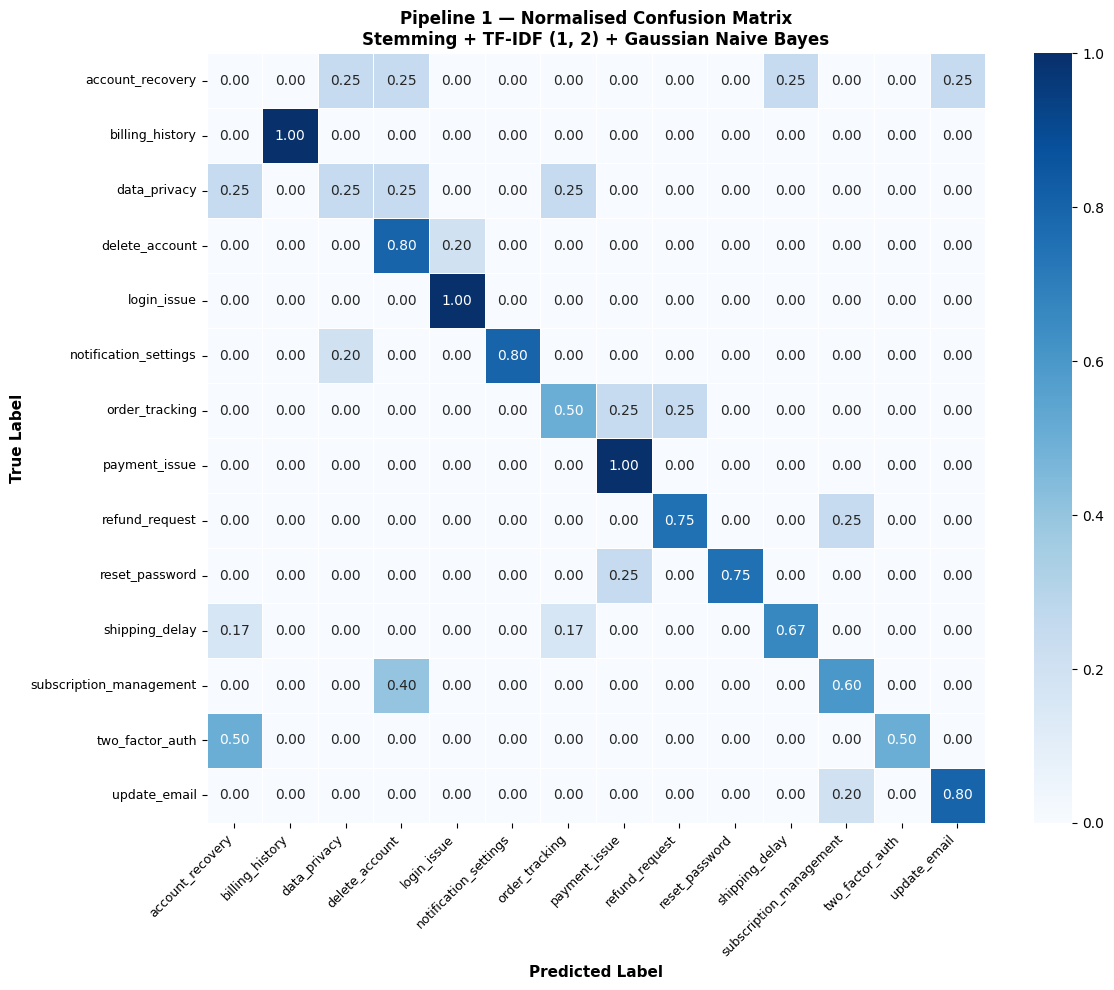

In [93]:
labels = sorted(set(y))
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.4, linecolor='white', ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label',      fontsize=11, fontweight='bold')
ax.set_title(
    f'Pipeline 1 — Normalised Confusion Matrix\n'
    f'Stemming + TF-IDF {BEST_NGRAM} + Gaussian Naive Bayes',
    fontsize=12, fontweight='bold'
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('p1_confusion_matrix.png', bbox_inches='tight')
plt.show()

### PCA Visualisation of TF-IDF Space

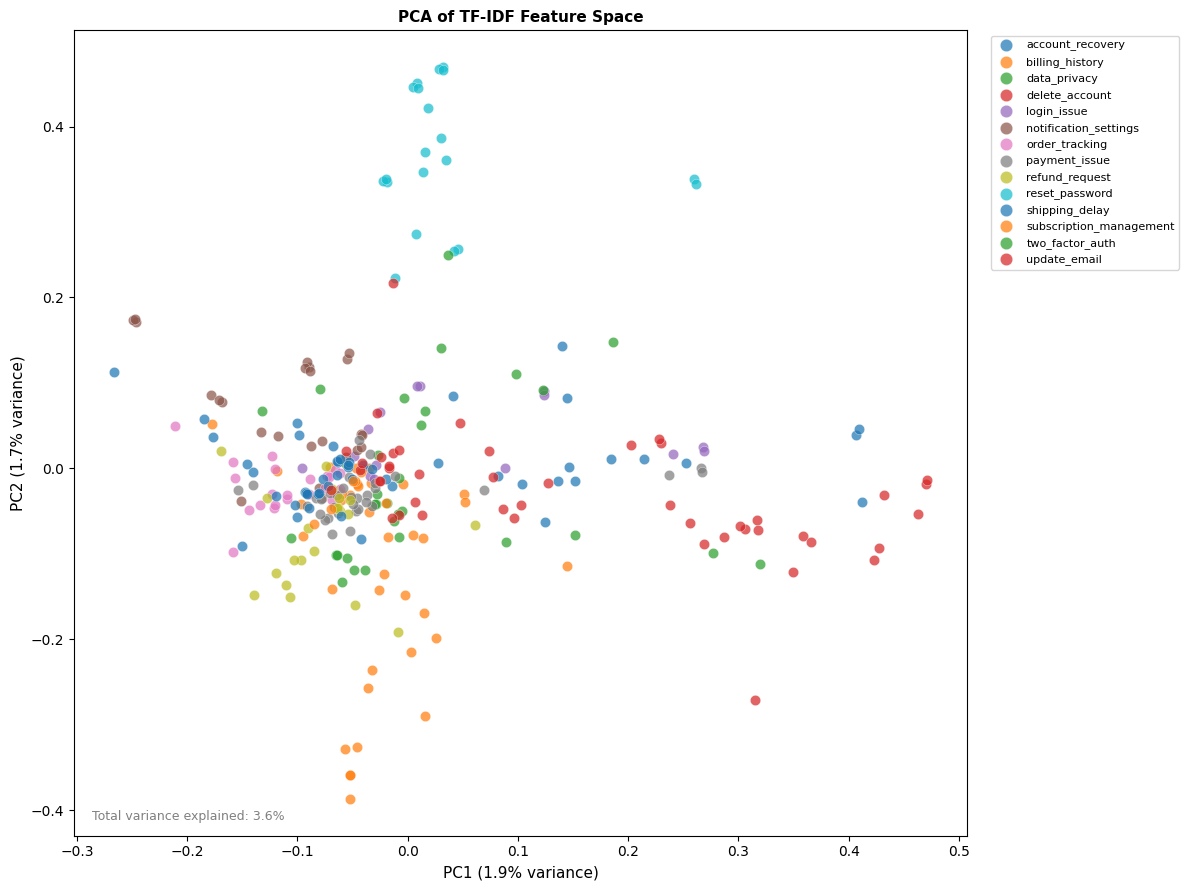

In [94]:
# Fit vectoriser on full dataset for visualisation
tfidf_viz = TfidfVectorizer(ngram_range=BEST_NGRAM, sublinear_tf=True, min_df=1)
X_all_feat = tfidf_viz.fit_transform(X).toarray()

pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_all_feat)

le = LabelEncoder()
y_enc = le.fit_transform(y)

fig, ax = plt.subplots(figsize=(12, 9))
for i, cls in enumerate(le.classes_):
    mask = (y_enc == i)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=PALETTE[i % len(PALETTE)],
               alpha=0.72, s=55, edgecolors='white', linewidths=0.3, label=cls)

total_var = pca.explained_variance_ratio_.sum() * 100
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA of TF-IDF Feature Space',
    fontsize=11, fontweight='bold'
)
ax.text(0.02, 0.02, f'Total variance explained: {total_var:.1f}%',
        transform=ax.transAxes, fontsize=9, color='grey')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, framealpha=0.8, markerscale=1.2)
plt.tight_layout()
plt.savefig('p1_pca.png', bbox_inches='tight')
plt.show()

### Error Analysis
Inspecting queries that were wrongly classified.

In [95]:
test_queries = df['query'].iloc[len(X_train):len(X_train)+len(X_test)].tolist()

errors = [
    {'query':q, 'true':t, 'predicted':p}
    for q, t, p in zip(test_queries, y_test, y_pred)
    if t != p
]

print(f"Misclassified: {len(errors)} / {len(y_test)}  "
      f"({len(errors)/len(y_test)*100:.1f}% error rate)\n")

print(f"{'Query':<50}  {'True Label':<25}  Predicted")
print('─' * 100)
for e in errors[:15]:
    print(f"{e['query'][:50]:<50}  {e['true']:<25}  {e['predicted']}")

print("\nMost common confusion pairs (true -> predicted):")
for (t, p), cnt in Counter(
        [(e['true'], e['predicted']) for e in errors]).most_common(6):
    print(f"  {t:<30} → {p:<30}  ({cnt}x)")

Misclassified: 19 / 62  (30.6% error rate)

Query                                               True Label                 Predicted
────────────────────────────────────────────────────────────────────────────────────────────────────
I'm unable to sign in — is this because my account  order_tracking             refund_request
alerts coming multiple times help pls               account_recovery           data_privacy
How do I reset my password within 48 hours; does t  account_recovery           update_email
order marked delivered but not received!            shipping_delay             order_tracking
contact support for payment issues?                 shipping_delay             account_recovery
Can I login from multiple devices at the same time  subscription_management    delete_account
refund processed but not credited wat to do?        update_email               subscription_management
Is it possible to reset my password from another d  reset_password             payment_issue
shipping

## Summary

In [96]:
print("=" * 52)
print("  PIPELINE 1 — RESULTS SUMMARY")
print("=" * 52)
print(f"  Pre-processing : Stemming")
print(f"  Representation : TF-IDF  ngram_range={BEST_NGRAM}")
print(f"  Classifier     : Gaussian Naive Bayes")
print('─' * 52)
print(f"  Accuracy       : {acc:.4f}")
print(f"  Macro Precision: {prec:.4f}")
print(f"  Macro Recall   : {rec:.4f}")
print(f"  Macro F1       : {f1:.4f}")
print("=" * 52)

  PIPELINE 1 — RESULTS SUMMARY
  Pre-processing : Stemming
  Representation : TF-IDF  ngram_range=(1, 2)
  Classifier     : Gaussian Naive Bayes
────────────────────────────────────────────────────
  Accuracy       : 0.6935
  Macro Precision: 0.7008
  Macro Recall   : 0.6726
  Macro F1       : 0.6731
